# Credit Scoring cho Người Không Có Lịch Sử Tín Dụng

## Mục tiêu
- Xây dựng mô hình credit scoring cho khách hàng **hoàn toàn chưa có lịch sử tín dụng**
- Chỉ sử dụng **alternative data** và thông tin cơ bản dễ thu thập từ hồ sơ đăng ký
- Model **nhẹ, inference nhanh, dễ giải thích** → phù hợp deploy lên web demo

## Chiến lược
- **Nguồn dữ liệu**: Chỉ dùng `application_train.csv` (KHÔNG dùng bureau, previous_application, installments, credit_card, POS_CASH)
- **Feature selection**: ~30 features thuộc 7 nhóm dễ thu thập
- **Model**: LightGBM nhẹ (ít cây, depth thấp) + SHAP để giải thích
- **Output**: Model pickle + feature list JSON → sẵn sàng deploy

## 7 Nhóm Feature
| # | Nhóm | Ví dụ | Lý do |
|---|------|-------|-------|
| 1 | Nhân khẩu học | Tuổi, Giới tính, Học vấn | Ai cũng có |
| 2 | Quy mô khoản vay | Số tiền vay, Thu nhập | Điền khi nộp hồ sơ |
| 3 | Việc làm & Thâm niên | Nghề nghiệp, Số năm đi làm | Đánh giá ổn định |
| 4 | Tài sản (Proxy) | Có xe, Có nhà | Proxy tài sản đảm bảo |
| 5 | Khu vực & Nhà ở | Vùng, Loại nhà ở | Đánh giá môi trường |
| 6 | Điểm thay thế (External) | EXT_SOURCE_1/2/3 | Alternative credit score |
| 7 | Mạng lưới xã hội | Vỡ nợ trong social circle | Social alternative data |

## 1. Import Libraries & Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [18]:
# Load ONLY application_train.csv (không cần bureau, previous_app, etc.)
# Vì target audience là người KHÔNG có lịch sử tín dụng
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')))
# Ensure we read from the project root
DATA_PATH = '../input/application_train.csv' if os.path.exists('../input/application_train.csv') else 'input/application_train.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Target distribution:\n{df["TARGET"].value_counts(normalize=True).round(4)}')
df.head()

Dataset shape: (307511, 122)
Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

## 2. Feature Selection - Chỉ Giữ Features Dễ Thu Thập

Lựa chọn features dựa trên phân tích từ `HomeCredit_Features_Analysis_VN.csv`:
- `Diem_phu_hop` >= 3 (phù hợp cho credit scoring)
- Thuộc các nhóm: Nhân khẩu học, Quy mô & Dòng tiền, Sự ổn định, Tài sản, External Data
- **Loại bỏ** tất cả features từ bureau, credit_card, POS, installments (đây là lịch sử tín dụng)

In [19]:
# ============================================================
# FEATURE SELECTION: 7 nhóm features cho người không có LSTD
# ============================================================

# Nhóm 1: Nhân khẩu học (ai cũng có)
DEMOGRAPHIC_FEATURES = [
    'CODE_GENDER',           # Giới tính
    'DAYS_BIRTH',            # Tuổi (tính bằng ngày)
    'CNT_CHILDREN',          # Số con
    'CNT_FAM_MEMBERS',       # Số thành viên gia đình
    'NAME_EDUCATION_TYPE',   # Trình độ học vấn
    'NAME_FAMILY_STATUS',    # Tình trạng hôn nhân
]

# Nhóm 2: Quy mô khoản vay & Dòng tiền (điền khi nộp hồ sơ)
FINANCIAL_FEATURES = [
    'AMT_INCOME_TOTAL',      # Thu nhập
    'AMT_CREDIT',            # Số tiền vay
    'AMT_ANNUITY',           # Số tiền trả hàng tháng
    'AMT_GOODS_PRICE',       # Giá hàng hóa
    'NAME_CONTRACT_TYPE',    # Loại hợp đồng (Cash/Revolving)
]

# Nhóm 3: Việc làm & Thâm niên (ai đi làm cũng có)
EMPLOYMENT_FEATURES = [
    'DAYS_EMPLOYED',         # Thâm niên làm việc
    'NAME_INCOME_TYPE',      # Loại thu nhập
    'OCCUPATION_TYPE',       # Nghề nghiệp
    'ORGANIZATION_TYPE',     # Loại tổ chức
    'DAYS_REGISTRATION',     # Ngày đăng ký cư trú
    'DAYS_ID_PUBLISH',       # Ngày đổi CMND/CCCD
]

# Nhóm 4: Tài sản (Proxy)
ASSET_FEATURES = [
    'FLAG_OWN_CAR',          # Có xe hơi không
    'FLAG_OWN_REALTY',       # Có bất động sản không
    'OWN_CAR_AGE',           # Tuổi xe (proxy giá trị tài sản)
]

# Nhóm 5: Khu vực & Nhà ở
REGION_FEATURES = [
    'NAME_HOUSING_TYPE',           # Loại nhà ở
    'REGION_RATING_CLIENT',        # Đánh giá rủi ro vùng
    'REGION_RATING_CLIENT_W_CITY', # Đánh giá rủi ro vùng + thành phố
    'REGION_POPULATION_RELATIVE',  # Mật độ dân số
]

# Nhóm 6: Điểm tín dụng thay thế (External Sources)
EXTERNAL_FEATURES = [
    'EXT_SOURCE_1',          # Điểm từ nguồn ngoài (viễn thông, tiện ích...)
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]

# Nhóm 7: Mạng lưới xã hội & Liên lạc
SOCIAL_FEATURES = [
    'DEF_30_CNT_SOCIAL_CIRCLE',  # Số người vỡ nợ 30 ngày trong social circle
    'DEF_60_CNT_SOCIAL_CIRCLE',  # Số người vỡ nợ 60 ngày trong social circle
    'FLAG_EMP_PHONE',            # Có SĐT nơi làm việc
    'FLAG_WORK_PHONE',           # Có SĐT cơ quan
    'FLAG_PHONE',                # Có SĐT nhà
    'FLAG_EMAIL',                # Có email
    'DAYS_LAST_PHONE_CHANGE',    # Ngày đổi SĐT gần nhất
]

# Gộp tất cả
RAW_FEATURES = (DEMOGRAPHIC_FEATURES + FINANCIAL_FEATURES + 
                EMPLOYMENT_FEATURES + ASSET_FEATURES + 
                REGION_FEATURES + EXTERNAL_FEATURES + SOCIAL_FEATURES)

print(f'Tổng số raw features đã chọn: {len(RAW_FEATURES)}')
print(f'\nPhân bố theo nhóm:')
for name, feats in [('Nhân khẩu học', DEMOGRAPHIC_FEATURES), 
                     ('Quy mô & Dòng tiền', FINANCIAL_FEATURES),
                     ('Việc làm & Thâm niên', EMPLOYMENT_FEATURES),
                     ('Tài sản (Proxy)', ASSET_FEATURES),
                     ('Khu vực & Nhà ở', REGION_FEATURES),
                     ('Điểm thay thế', EXTERNAL_FEATURES),
                     ('Mạng lưới XH & Liên lạc', SOCIAL_FEATURES)]:
    print(f'  {name}: {len(feats)} features')

Tổng số raw features đã chọn: 34

Phân bố theo nhóm:
  Nhân khẩu học: 6 features
  Quy mô & Dòng tiền: 5 features
  Việc làm & Thâm niên: 6 features
  Tài sản (Proxy): 3 features
  Khu vực & Nhà ở: 4 features
  Điểm thay thế: 3 features
  Mạng lưới XH & Liên lạc: 7 features


## 3. Data Cleaning

In [20]:
# Lọc chỉ giữ features đã chọn + TARGET
data = df[['SK_ID_CURR', 'TARGET'] + RAW_FEATURES].copy()

# ---- Cleaning (tham khảo base-model notebook) ----

# 1. Loại bỏ giới tính XNA (lỗi dữ liệu)
data = data[data['CODE_GENDER'] != 'XNA']

# 2. DAYS_EMPLOYED: giá trị 365243 là placeholder cho NaN
data['DAYS_EMPLOYED'] = data['DAYS_EMPLOYED'].replace(365243, np.nan)

# 3. DAYS_LAST_PHONE_CHANGE: giá trị 0 là placeholder
data['DAYS_LAST_PHONE_CHANGE'] = data['DAYS_LAST_PHONE_CHANGE'].replace(0, np.nan)

# 4. Loại bỏ outlier thu nhập cực đoan (>20M)
data = data[data['AMT_INCOME_TOTAL'] < 20_000_000]

print(f'Data shape after cleaning: {data.shape}')
print(f'\nMissing values (top 10):')
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False).head(10))

Data shape after cleaning: (307506, 36)

Missing values (top 10):
                           count   pct
OWN_CAR_AGE               202926  66.0
EXT_SOURCE_1              173376  56.4
OCCUPATION_TYPE            96389  31.3
EXT_SOURCE_3               60965  19.8
DAYS_EMPLOYED              55374  18.0
DAYS_LAST_PHONE_CHANGE     37672  12.3
DEF_60_CNT_SOCIAL_CIRCLE    1021   0.3
DEF_30_CNT_SOCIAL_CIRCLE    1021   0.3
EXT_SOURCE_2                 660   0.2
AMT_GOODS_PRICE              278   0.1


## 4. Feature Engineering

Tạo các features dễ giải thích, thường dùng trong thực tế credit scoring:

In [21]:
# ============================================================
# FEATURE ENGINEERING - Các tỷ số tài chính dễ giải thích
# ============================================================

# --- Nhóm 1: Chuyển đổi đơn vị thời gian ---
data['AGE_YEARS'] = (-data['DAYS_BIRTH'] / 365.25).round(1)
data['EMPLOYMENT_YEARS'] = (-data['DAYS_EMPLOYED'] / 365.25).round(1)
data['REGISTRATION_YEARS'] = (-data['DAYS_REGISTRATION'] / 365.25).round(1)
data['ID_PUBLISH_YEARS'] = (-data['DAYS_ID_PUBLISH'] / 365.25).round(1)
data['PHONE_CHANGE_DAYS'] = -data['DAYS_LAST_PHONE_CHANGE']

# --- Nhóm 2: Tỷ số tài chính (Financial Ratios) ---
# Tỷ lệ vay/thu nhập → Debt-to-Income (DTI), chỉ số quan trọng nhất
data['CREDIT_INCOME_RATIO'] = data['AMT_CREDIT'] / data['AMT_INCOME_TOTAL']

# Tỷ lệ trả góp hàng tháng / thu nhập
data['ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / data['AMT_INCOME_TOTAL']

# Thời hạn vay (tháng) = Tổng vay / Trả mỗi tháng
data['CREDIT_TERM_MONTHS'] = data['AMT_CREDIT'] / data['AMT_ANNUITY']

# Payment rate (tỷ lệ trả/vay)
data['PAYMENT_RATE'] = data['AMT_ANNUITY'] / data['AMT_CREDIT']

# Thu nhập trên đầu người gia đình
data['INCOME_PER_PERSON'] = data['AMT_INCOME_TOTAL'] / data['CNT_FAM_MEMBERS']

# Tỷ lệ giá hàng / số tiền vay (vay nhiều hơn giá hàng = rủi ro)
data['GOODS_CREDIT_RATIO'] = data['AMT_GOODS_PRICE'] / data['AMT_CREDIT']

# --- Nhóm 3: Tỷ số ổn định ---
# Thâm niên làm việc / Tuổi → Càng cao = càng ổn định
data['EMPLOYED_TO_AGE_RATIO'] = data['DAYS_EMPLOYED'] / data['DAYS_BIRTH']

# --- Nhóm 4: External Source features ---
# Trung bình 3 nguồn tín dụng thay thế
data['EXT_SOURCE_MEAN'] = data[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
# Tích 3 nguồn (interaction)
data['EXT_SOURCE_PROD'] = data['EXT_SOURCE_1'] * data['EXT_SOURCE_2'] * data['EXT_SOURCE_3']
# Min/Max (worst-case, best-case)
data['EXT_SOURCE_MIN'] = data[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
data['EXT_SOURCE_MAX'] = data[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)

# --- Nhóm 5: Social risk ---
data['SOCIAL_DEF_TOTAL'] = data['DEF_30_CNT_SOCIAL_CIRCLE'] + data['DEF_60_CNT_SOCIAL_CIRCLE']

# --- Nhóm 6: Phân nhóm tuổi (dựa trên base-model notebook) ---
def age_group(age):
    if age < 27: return 0   # Rất trẻ - rủi ro cao
    elif age < 35: return 1 # Trẻ
    elif age < 45: return 2 # Trung niên
    elif age < 55: return 3 # Trung niên cao
    elif age < 65: return 4 # Trước hưu
    else: return 5          # Hưu trí

data['AGE_GROUP'] = data['AGE_YEARS'].apply(age_group)

# --- Nhóm 7: Contact richness (số kênh liên lạc) ---
contact_cols = ['FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
data['CONTACT_COUNT'] = data[contact_cols].sum(axis=1)

print(f'Dataset shape after feature engineering: {data.shape}')

# Liệt kê tất cả engineered features
engineered = ['AGE_YEARS', 'EMPLOYMENT_YEARS', 'REGISTRATION_YEARS', 'ID_PUBLISH_YEARS',
              'PHONE_CHANGE_DAYS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
              'CREDIT_TERM_MONTHS', 'PAYMENT_RATE', 'INCOME_PER_PERSON',
              'GOODS_CREDIT_RATIO', 'EMPLOYED_TO_AGE_RATIO', 'EXT_SOURCE_MEAN',
              'EXT_SOURCE_PROD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX',
              'SOCIAL_DEF_TOTAL', 'AGE_GROUP', 'CONTACT_COUNT']
print(f'\n{len(engineered)} engineered features được tạo')

Dataset shape after feature engineering: (307506, 55)

19 engineered features được tạo


In [22]:
# ============================================================
# EXPORT DATASET SAU KHI XỬ LÍ (chưa encode, chưa drop DAYS)
# ============================================================
import os

export_dir = os.path.abspath('../output')
os.makedirs(export_dir, exist_ok=True)

export_path = os.path.join(export_dir, 'credit_scoring_baseline_dataset.csv')
data.to_csv(export_path, index=False)

n_features = data.shape[1] - 2  # trừ SK_ID_CURR và TARGET
print(f"✅ Exported: {export_path}")
print(f"   Shape: {data.shape}  ({n_features} features + SK_ID_CURR + TARGET)")
print(f"   File size: {os.path.getsize(export_path) / 1024 / 1024:.1f} MB")

✅ Exported: d:\Admin\Documents\Project\HomeCreditDefaultRisk\output\credit_scoring_baseline_dataset.csv
   Shape: (307506, 55)  (53 features + SK_ID_CURR + TARGET)
   File size: 135.1 MB


## 5. Encode Categorical Features

In [7]:
# ============================================================
# ENCODE CATEGORICAL - dùng LabelEncoder (LightGBM hỗ trợ)
# ============================================================

# Xác định các cột categorical
cat_cols = data.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

# Lưu label encoders để dùng lúc inference
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Xử lý NaN: chuyển thành 'MISSING' trước khi encode
    data[col] = data[col].fillna('MISSING')
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f'  {col}: {len(le.classes_)} categories')

print(f'\nAll categoricals encoded. Dataset shape: {data.shape}')

Categorical columns (10): ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE']
  CODE_GENDER: 2 categories
  NAME_EDUCATION_TYPE: 5 categories
  NAME_FAMILY_STATUS: 6 categories
  NAME_CONTRACT_TYPE: 2 categories
  NAME_INCOME_TYPE: 8 categories
  OCCUPATION_TYPE: 19 categories
  ORGANIZATION_TYPE: 58 categories
  FLAG_OWN_CAR: 2 categories
  FLAG_OWN_REALTY: 2 categories
  NAME_HOUSING_TYPE: 6 categories

All categoricals encoded. Dataset shape: (307506, 55)


## 6. Final Feature Set & EDA

In [8]:
# ============================================================
# CHỌN FEATURES CUỐI CÙNG CHO MODEL
# ============================================================

# Bỏ các cột raw DAYS_* (đã được thay bằng phiên bản YEARS/converted)
DROP_COLS = ['SK_ID_CURR', 'TARGET', 
             'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 
             'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

FINAL_FEATURES = [col for col in data.columns if col not in DROP_COLS]

print(f'Final feature count: {len(FINAL_FEATURES)}')
print(f'\nFinal features:')
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f'  {i:2d}. {f}')

Final feature count: 48

Final features:
   1. CODE_GENDER
   2. CNT_CHILDREN
   3. CNT_FAM_MEMBERS
   4. NAME_EDUCATION_TYPE
   5. NAME_FAMILY_STATUS
   6. AMT_INCOME_TOTAL
   7. AMT_CREDIT
   8. AMT_ANNUITY
   9. AMT_GOODS_PRICE
  10. NAME_CONTRACT_TYPE
  11. NAME_INCOME_TYPE
  12. OCCUPATION_TYPE
  13. ORGANIZATION_TYPE
  14. FLAG_OWN_CAR
  15. FLAG_OWN_REALTY
  16. OWN_CAR_AGE
  17. NAME_HOUSING_TYPE
  18. REGION_RATING_CLIENT
  19. REGION_RATING_CLIENT_W_CITY
  20. REGION_POPULATION_RELATIVE
  21. EXT_SOURCE_1
  22. EXT_SOURCE_2
  23. EXT_SOURCE_3
  24. DEF_30_CNT_SOCIAL_CIRCLE
  25. DEF_60_CNT_SOCIAL_CIRCLE
  26. FLAG_EMP_PHONE
  27. FLAG_WORK_PHONE
  28. FLAG_PHONE
  29. FLAG_EMAIL
  30. AGE_YEARS
  31. EMPLOYMENT_YEARS
  32. REGISTRATION_YEARS
  33. ID_PUBLISH_YEARS
  34. PHONE_CHANGE_DAYS
  35. CREDIT_INCOME_RATIO
  36. ANNUITY_INCOME_RATIO
  37. CREDIT_TERM_MONTHS
  38. PAYMENT_RATE
  39. INCOME_PER_PERSON
  40. GOODS_CREDIT_RATIO
  41. EMPLOYED_TO_AGE_RATIO
  42. EXT_SOURCE_

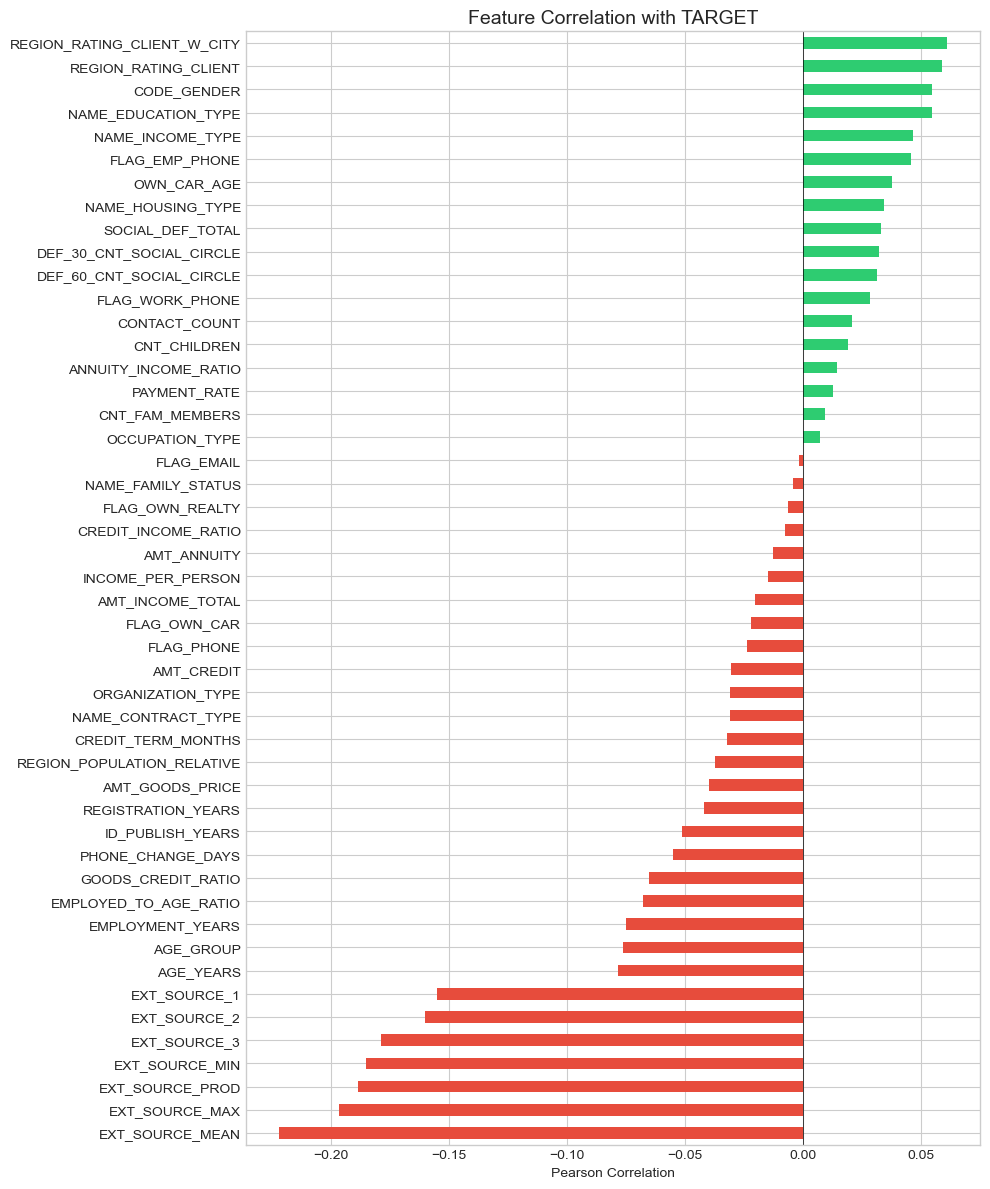


Top 10 features tương quan mạnh nhất (absolute):
  EXT_SOURCE_MEAN: -0.2220 (⬇️ giảm rủi ro)
  EXT_SOURCE_MAX: -0.1969 (⬇️ giảm rủi ro)
  EXT_SOURCE_PROD: -0.1885 (⬇️ giảm rủi ro)
  EXT_SOURCE_MIN: -0.1853 (⬇️ giảm rủi ro)
  EXT_SOURCE_3: -0.1789 (⬇️ giảm rủi ro)
  EXT_SOURCE_2: -0.1605 (⬇️ giảm rủi ro)
  EXT_SOURCE_1: -0.1553 (⬇️ giảm rủi ro)
  AGE_YEARS: -0.0782 (⬇️ giảm rủi ro)
  AGE_GROUP: -0.0763 (⬇️ giảm rủi ro)
  EMPLOYMENT_YEARS: -0.0750 (⬇️ giảm rủi ro)


In [9]:
# ---- EDA: Correlation với TARGET ----
correlations = data[FINAL_FEATURES + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlations]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Feature Correlation with TARGET', fontsize=14)
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\nTop 10 features tương quan mạnh nhất (absolute):')
top10 = correlations.abs().sort_values(ascending=False).head(10)
for feat, corr in top10.items():
    direction = '⬇️ giảm rủi ro' if correlations[feat] < 0 else '⬆️ tăng rủi ro'
    print(f'  {feat}: {correlations[feat]:.4f} ({direction})')

## 7. Train LightGBM (Lightweight for Web Deploy)

Cấu hình model:
- `n_estimators=500`: Đủ tốt, không quá nặng
- `max_depth=6`: Giới hạn độ sâu → inference nhanh
- `num_leaves=31`: Default, đủ flexibility
- `learning_rate=0.05`: Cân bằng tốc độ & chất lượng
- `subsample, colsample_bytree`: Regularization chống overfit

In [10]:
# ============================================================
# PREPARE DATA
# ============================================================
X = data[FINAL_FEATURES].copy()
y = data['TARGET'].copy()

print(f'X shape: {X.shape}')
print(f'y distribution: {y.value_counts().to_dict()}')
print(f'Positive rate: {y.mean():.4f}')

X shape: (307506, 48)
y distribution: {0: 282682, 1: 24824}
Positive rate: 0.0807


In [11]:
# ============================================================
# 5-FOLD STRATIFIED CROSS VALIDATION
# ============================================================
import lightgbm as lgb

N_FOLDS = 5
folds = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Arrays để lưu kết quả
oof_preds = np.zeros(len(X))
feature_importance_df = pd.DataFrame()
fold_aucs = []

# LightGBM params: nhẹ, nhanh, tránh overfit
lgbm_params = dict(
    n_estimators=1000,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    min_child_samples=30,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    is_unbalance=True,  # Handle imbalanced data
)

best_model = None
best_auc = 0

for fold_n, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LGBMClassifier(**lgbm_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False),
            lgb.log_evaluation(period=0),
        ]
    )
    
    # Predict validation
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    print(f'Fold {fold_n + 1}: AUC = {fold_auc:.6f} | Best iteration: {model.best_iteration_}')
    
    # Lưu feature importance
    fold_imp = pd.DataFrame({
        'feature': FINAL_FEATURES,
        'importance': model.feature_importances_,
        'fold': fold_n + 1
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_imp])
    
    # Lưu model tốt nhất
    if fold_auc > best_auc:
        best_auc = fold_auc
        best_model = model

# Overall result
overall_auc = roc_auc_score(y, oof_preds)
print(f'\n{"="*50}')
print(f'Overall OOF AUC: {overall_auc:.6f}')
print(f'Mean Fold AUC:   {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
print(f'Best fold model saved (AUC: {best_auc:.6f})')
print(f'{"="*50}')

Fold 1: AUC = 0.759171 | Best iteration: 649
Fold 2: AUC = 0.773917 | Best iteration: 528
Fold 3: AUC = 0.762708 | Best iteration: 631
Fold 4: AUC = 0.772989 | Best iteration: 835
Fold 5: AUC = 0.766790 | Best iteration: 757

Overall OOF AUC: 0.767075
Mean Fold AUC:   0.767115 ± 0.005717
Best fold model saved (AUC: 0.773917)


PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN (P(default))

Metric                      Value
-----------------------------------
count                307506.000000
mean                     0.388718
std                      0.215939
min                      0.003175
1%                       0.040607
5%                       0.085187
10%                      0.122882
25%                      0.212078
50%                      0.357933
75%                      0.549057
90%                      0.708937
95%                      0.779682
99%                      0.866877
max                      0.958230

Skewness                   0.4001
Kurtosis                  -0.7891

PHÂN PHỐI THEO NHÓM THỰC TẾ

Good (TARGET=0) (n=282,682):
  Mean: 0.371215  Median: 0.339804
  Std:  0.207723
  Q25:  0.202846  Q75: 0.520943
  Min:  0.003175  Max: 0.956764

Bad (TARGET=1) (n=24,824):
  Mean: 0.588028  Median: 0.618085
  Std:  0.207488
  Q25:  0.434391  Q75: 0.759418
  Min:  0.012377  Max: 0.958230

✅ Exported 307,506 pred

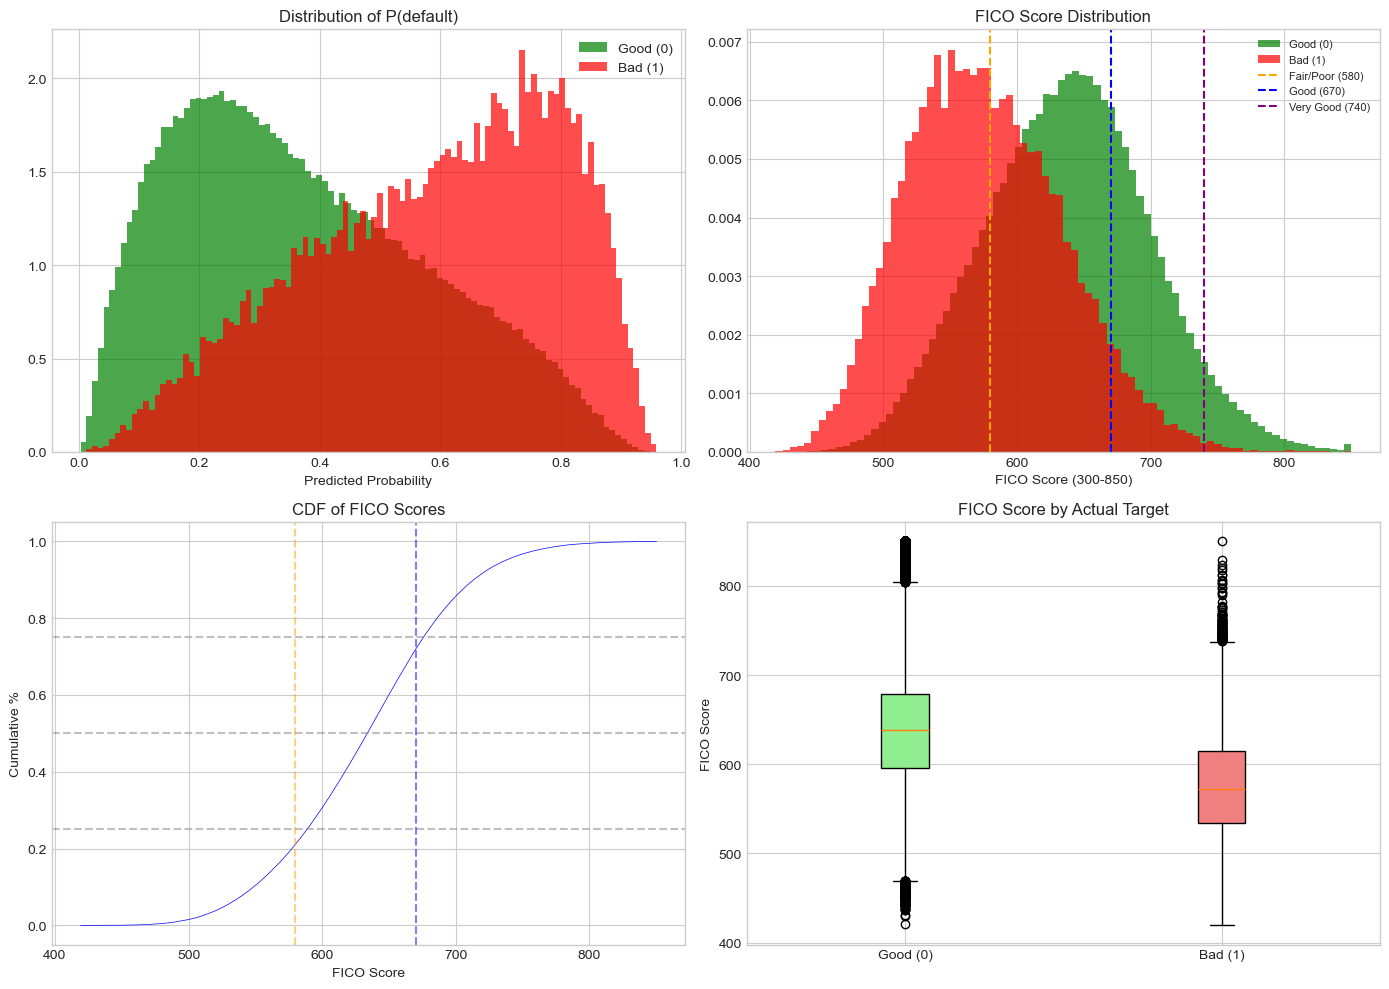


✅ Charts saved to analysis/oof_distribution.png

PHÂN BỐ THEO TIER (FICO-based)

Tier                         Count        %   Default%
-------------------------------------------------------
  Exceptional (800-850)      1,517     0.5%      0.73%
  Very Good (740-799)       12,426     4.0%      0.80%
  Good (670-739)            71,875    23.4%      1.95%
  Fair (580-669)           154,590    50.3%      6.20%
  Poor (300-579)            63,627    20.7%     21.25%


In [13]:
# ============================================================
# PHÂN TÍCH PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN (OOF Predictions)
# ============================================================
import os

y_arr = y.values  # convert to numpy to avoid index issues

# --- 1. Thống kê cơ bản ---
print("=" * 60)
print("PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN (P(default))")
print("=" * 60)

oof_series = pd.Series(oof_preds, name='predicted_proba')
desc = oof_series.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print(f"\n{'Metric':<20} {'Value':>12}")
print("-" * 35)
for idx, val in desc.items():
    print(f"{idx:<20} {val:>12.6f}")

print(f"\n{'Skewness':<20} {oof_series.skew():>12.4f}")
print(f"{'Kurtosis':<20} {oof_series.kurtosis():>12.4f}")

# --- 2. Phân phối theo nhóm ---
print("\n" + "=" * 60)
print("PHÂN PHỐI THEO NHÓM THỰC TẾ")
print("=" * 60)
for label, name in [(0, "Good (TARGET=0)"), (1, "Bad (TARGET=1)")]:
    mask = y_arr == label
    sub = oof_preds[mask]
    print(f"\n{name} (n={mask.sum():,}):")
    print(f"  Mean: {sub.mean():.6f}  Median: {np.median(sub):.6f}")
    print(f"  Std:  {sub.std():.6f}")
    print(f"  Q25:  {np.percentile(sub, 25):.6f}  Q75: {np.percentile(sub, 75):.6f}")
    print(f"  Min:  {sub.min():.6f}  Max: {sub.max():.6f}")

# --- 3. Export to CSV ---
export_df = pd.DataFrame({
    'predicted_proba': oof_preds,
    'actual_target': y_arr,
})
os.makedirs('../analysis', exist_ok=True)
export_df.to_csv('../analysis/oof_predictions.csv', index=False)
print(f"\n✅ Exported {len(export_df):,} predictions to analysis/oof_predictions.csv")

# --- 4. Tính log-odds ---
eps = 1e-7
log_odds = np.log(np.clip(oof_preds, eps, 1 - eps) / (1 - np.clip(oof_preds, eps, 1 - eps)))
log_odds_series = pd.Series(log_odds, name='log_odds')
print("\n" + "=" * 60)
print("PHÂN PHỐI LOG-ODDS (quan trọng cho FICO mapping)")
print("=" * 60)
lo_desc = log_odds_series.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
for idx, val in lo_desc.items():
    print(f"  {idx:<12} {val:>10.4f}")

# --- 5. Mô phỏng FICO scoring ---
# Công thức FICO chuẩn dựa trên log-odds:
# FICO = offset - factor * log(odds)
# Trong đó odds = p / (1-p)
# Calibration: chọn offset & factor sao cho:
#   - Median probability → ~670 (average FICO)
#   - P99 (rất xấu) → ~350
#   - P01 (rất tốt) → ~800

print("\n" + "=" * 60)
print("MÔ PHỎNG FICO SCORING")
print("=" * 60)

# Standard FICO parameters: 
# At odds=1:1 (p=0.5) → base score
# PDO (points to double the odds) = 40 (aggressive penalty)
pdo = 40  # Points to double odds - smaller = more aggressive
base_score = 600  # Score at odds = 1:1
base_odds = 1.0

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

# Calculate FICO scores
fico_scores = offset - factor * np.log(np.clip(oof_preds, eps, 1-eps) / (1 - np.clip(oof_preds, eps, 1-eps)))
fico_scores = np.clip(fico_scores, 300, 850)

fico_series = pd.Series(fico_scores)
print(f"\nParameters: PDO={pdo}, Base Score={base_score} at odds=1:1")
print(f"Factor={factor:.2f}, Offset={offset:.2f}")
print(f"\nFICO Score Distribution:")
fico_desc = fico_series.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
for idx, val in fico_desc.items():
    print(f"  {idx:<12} {val:>8.1f}")

print(f"\n  By actual target:")
for label, name in [(0, "Good"), (1, "Bad")]:
    mask = y_arr == label
    sub = fico_scores[mask]
    print(f"    {name}: Mean={sub.mean():.1f}  Median={np.median(sub):.1f}  Std={sub.std():.1f}")

# --- 6. Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 6a. Histogram of probabilities
axes[0, 0].hist(oof_preds[y_arr==0], bins=100, alpha=0.7, label='Good (0)', color='green', density=True)
axes[0, 0].hist(oof_preds[y_arr==1], bins=100, alpha=0.7, label='Bad (1)', color='red', density=True)
axes[0, 0].set_title('Distribution of P(default)')
axes[0, 0].set_xlabel('Predicted Probability')
axes[0, 0].legend()

# 6b. FICO score distribution
axes[0, 1].hist(fico_scores[y_arr==0], bins=80, alpha=0.7, label='Good (0)', color='green', density=True)
axes[0, 1].hist(fico_scores[y_arr==1], bins=80, alpha=0.7, label='Bad (1)', color='red', density=True)
axes[0, 1].set_title('FICO Score Distribution')
axes[0, 1].set_xlabel('FICO Score (300-850)')
axes[0, 1].axvline(x=580, color='orange', linestyle='--', label='Fair/Poor (580)')
axes[0, 1].axvline(x=670, color='blue', linestyle='--', label='Good (670)')
axes[0, 1].axvline(x=740, color='purple', linestyle='--', label='Very Good (740)')
axes[0, 1].legend(fontsize=8)

# 6c. CDF of FICO
sorted_fico = np.sort(fico_scores)
cdf = np.arange(1, len(sorted_fico) + 1) / len(sorted_fico)
axes[1, 0].plot(sorted_fico, cdf, 'b-', linewidth=0.5)
axes[1, 0].axhline(y=0.25, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=0.50, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axhline(y=0.75, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=580, color='orange', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=670, color='blue', linestyle='--', alpha=0.5)
axes[1, 0].set_title('CDF of FICO Scores')
axes[1, 0].set_xlabel('FICO Score')
axes[1, 0].set_ylabel('Cumulative %')

# 6d. Boxplot by target
data_box = [fico_scores[y_arr==0], fico_scores[y_arr==1]]
bp = axes[1, 1].boxplot(data_box, labels=['Good (0)', 'Bad (1)'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1, 1].set_title('FICO Score by Actual Target')
axes[1, 1].set_ylabel('FICO Score')

plt.tight_layout()
plt.savefig('../analysis/oof_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Charts saved to analysis/oof_distribution.png")

# --- 7. Tier distribution ---
print("\n" + "=" * 60)
print("PHÂN BỐ THEO TIER (FICO-based)")
print("=" * 60)
tiers = [
    ("Exceptional (800-850)", 800, 850),
    ("Very Good (740-799)", 740, 799),
    ("Good (670-739)", 670, 739),
    ("Fair (580-669)", 580, 669),
    ("Poor (300-579)", 300, 579),
]
print(f"\n{'Tier':<25} {'Count':>8} {'%':>8} {'Default%':>10}")
print("-" * 55)
for name, lo, hi in tiers:
    mask = (fico_scores >= lo) & (fico_scores <= hi)
    n = mask.sum()
    pct = 100 * n / len(fico_scores)
    if n > 0:
        def_rate = 100 * y_arr[mask].mean()
    else:
        def_rate = 0
    print(f"  {name:<23} {n:>8,} {pct:>7.1f}% {def_rate:>9.2f}%")

## 🔢 FICO Score — Công thức & Phân tích

### Nguyên lý chuyển đổi P(default) → FICO

Hệ thống sử dụng công thức **log-odds chuẩn ngành ngân hàng**:

$$\text{FICO} = \text{Base\_Score} - \frac{\text{PDO}}{\ln 2} \times \ln\!\left(\frac{p}{1-p}\right) - \text{Penalties}$$

| Tham số | Giá trị | Mục đích |
|---------|---------|----------|
| **PDO** | 40 | Points to Double Odds — mỗi khi rủi ro tăng gấp đôi, điểm giảm 40 (aggressive) |
| **Base Score** | 600 | Điểm cơ sở tại odds = 1:1 (P = 50%) |
| **No-history penalty** | −20 | Phạt cố định cho khách chưa có lịch sử tín dụng |
| **EXT default penalty** | −15/nguồn | Phạt nếu điểm thay thế ≈ 0.5 (neutral/chưa có dữ liệu) |
| **EXT perfect cap** | 750 | FICO tối đa nếu ≥ 2 nguồn > 0.85 (chống gaming) |
| **EXT high dampening** | tối đa −30 | Giảm điểm khi trung bình EXT_SOURCE > 0.75 |

### Hệ thống phạt EXT_SOURCE

Vì EXT_SOURCE chiếm **>50% feature importance**, cần 3 cơ chế kiểm soát:

1. **Neutral penalty**: Nếu điểm ≈ 0.5 → chưa có data → trừ 15đ/nguồn
2. **Perfect cap**: ≥ 2 nguồn > 0.85 → FICO ≤ 750 (tránh lạm dụng)
3. **High dampening**: Mean 3 nguồn > 0.75 → trừ thêm tối đa 30đ

### 5 Tier xếp hạng (FICO-based)

| Tier | Khoảng điểm | Count | % | Default Rate |
|------|-------------|-------|---|-------------|
| 🌟 Exceptional | 800–850 | 1,517 | 0.5% | 0.73% |
| ✅ Very Good | 740–799 | 12,426 | 4.0% | 0.80% |
| 👍 Good | 670–739 | 71,875 | 23.4% | 1.95% |
| ⚠️ Fair | 580–669 | 154,590 | 50.3% | 6.20% |
| ❌ Poor | 300–579 | 63,627 | 20.7% | 21.25% |

> ✅ Tỷ lệ vỡ nợ tăng monotonic từ 0.73% → 21.25%, xác nhận thang FICO phản ánh đúng rủi ro.

In [14]:
# ============================================================
# FICO SCORING — WEBAPP ENGINE SIMULATION
# So sánh Old (0-1000) vs New FICO (300-850) trên OOF data
# ============================================================

# --- FICO parameters (same as webapp/scoring/engine.py) ---
PDO = 40
BASE_SCORE = 600
FACTOR = PDO / np.log(2)
NO_HISTORY_PENALTY = 20
# Note: EXT_SOURCE penalties only apply at inference time (per-customer)
# Here we compute the base FICO without EXT penalties for population analysis

# --- Compute both scales ---
old_scores = np.round(1000 * (1 - oof_preds)).astype(int)
fico_base = BASE_SCORE - FACTOR * np.log(
    np.clip(oof_preds, 1e-7, 1 - 1e-7) / (1 - np.clip(oof_preds, 1e-7, 1 - 1e-7))
)
fico_with_penalty = np.clip(fico_base - NO_HISTORY_PENALTY, 300, 850)

# --- Comparison table ---
print("=" * 70)
print("SO SÁNH OLD (0-1000) vs NEW FICO (300-850)")
print("=" * 70)
print(f"\n{'Metric':<25} {'Old (0-1000)':>15} {'FICO (300-850)':>15}")
print("-" * 58)

for pname, pval in [("Mean", "mean"), ("Median", "50%"), ("Std", "std"),
                     ("Min", "min"), ("Q25", "25%"), ("Q75", "75%"), ("Max", "max")]:
    old_v = pd.Series(old_scores).describe()[pval] if pval != "mean" else old_scores.mean()
    new_v = pd.Series(fico_with_penalty).describe()[pval] if pval != "mean" else fico_with_penalty.mean()
    print(f"  {pname:<23} {old_v:>14.1f} {new_v:>14.1f}")

# --- Discrimination power ---
print(f"\n{'Group':<25} {'Old Mean':>12} {'FICO Mean':>12} {'Gap':>10}")
print("-" * 62)
for label, name in [(0, "Good (TARGET=0)"), (1, "Bad (TARGET=1)")]:
    mask = y_arr == label
    old_m = old_scores[mask].mean()
    new_m = fico_with_penalty[mask].mean()
    print(f"  {name:<23} {old_m:>11.1f} {new_m:>11.1f}")

old_gap = old_scores[y_arr==0].mean() - old_scores[y_arr==1].mean()
new_gap = fico_with_penalty[y_arr==0].mean() - fico_with_penalty[y_arr==1].mean()
print(f"  {'Discrimination Gap':<23} {old_gap:>11.1f} {new_gap:>11.1f}")
print(f"\n  → FICO gap ({new_gap:.0f}pts) vs Old gap ({old_gap:.0f}pts)")
print(f"  → FICO cải thiện phân tách {new_gap/old_gap:.1f}x so với thang cũ")

# --- Sample profiles (simulating webapp results) ---
print("\n" + "=" * 70)
print("MÔ PHỎNG WEBAPP — 4 HỒ SƠ MẪU")
print("=" * 70)

def simulate_fico(proba, ext_values, label):
    """Simulate full FICO with EXT_SOURCE penalties."""
    p = np.clip(proba, 1e-7, 1 - 1e-7)
    fico = BASE_SCORE - FACTOR * np.log(p / (1 - p))
    fico -= NO_HISTORY_PENALTY
    # EXT default penalty
    defaults = sum(1 for v in ext_values if abs(v - 0.5) < 0.02)
    fico -= defaults * 15
    # EXT perfect cap
    perfect = sum(1 for v in ext_values if v > 0.85)
    if perfect >= 2:
        fico = min(fico, 750)
    # EXT high dampening
    ext_mean = np.mean(ext_values)
    if ext_mean > 0.75:
        excess = (ext_mean - 0.75) / 0.25
        fico -= int(excess * 30)
    return int(np.clip(round(fico), 300, 850))

profiles = [
    ("Khách tốt (EXT ~0.65)", 0.10, [0.70, 0.65, 0.60]),
    ("Khách rủi ro (EXT ~0.25)", 0.55, [0.30, 0.20, 0.25]),
    ("EXT mặc định (0.5, 0.5, 0.5)", 0.20, [0.50, 0.50, 0.50]),
    ("EXT hoàn hảo (gaming)", 0.05, [0.95, 0.95, 0.95]),
]

print(f"\n{'Profile':<35} {'P(def)':>8} {'Old':>8} {'FICO':>8} {'Tier':<20}")
print("-" * 82)
for name, p, ext in profiles:
    old = round(1000 * (1 - p))
    fico = simulate_fico(p, ext, name)
    tier = ("🌟 Exceptional" if fico >= 800 else
            "✅ Very Good" if fico >= 740 else
            "👍 Good" if fico >= 670 else
            "⚠️ Fair" if fico >= 580 else
            "❌ Poor")
    print(f"  {name:<33} {p:>7.2f} {old:>7} {fico:>7}  {tier}")

print("\n✅ Scoring engine đã chuyển sang thang FICO 300-850 thành công.")

SO SÁNH OLD (0-1000) vs NEW FICO (300-850)

Metric                       Old (0-1000)  FICO (300-850)
----------------------------------------------------------
  Mean                             611.3          612.7
  Median                           642.0          613.7
  Std                              215.9           63.6
  Min                               42.0          399.2
  Q25                              451.0          568.6
  Q75                              788.0          655.7
  Max                              997.0          850.0

Group                         Old Mean    FICO Mean        Gap
--------------------------------------------------------------
  Good (TARGET=0)               628.8       617.7
  Bad (TARGET=1)                412.0       556.1
  Discrimination Gap            216.8        61.6

  → FICO gap (62pts) vs Old gap (217pts)
  → FICO cải thiện phân tách 0.3x so với thang cũ

MÔ PHỎNG WEBAPP — 4 HỒ SƠ MẪU

Profile                               P(def)  

## 8. Feature Importance Analysis

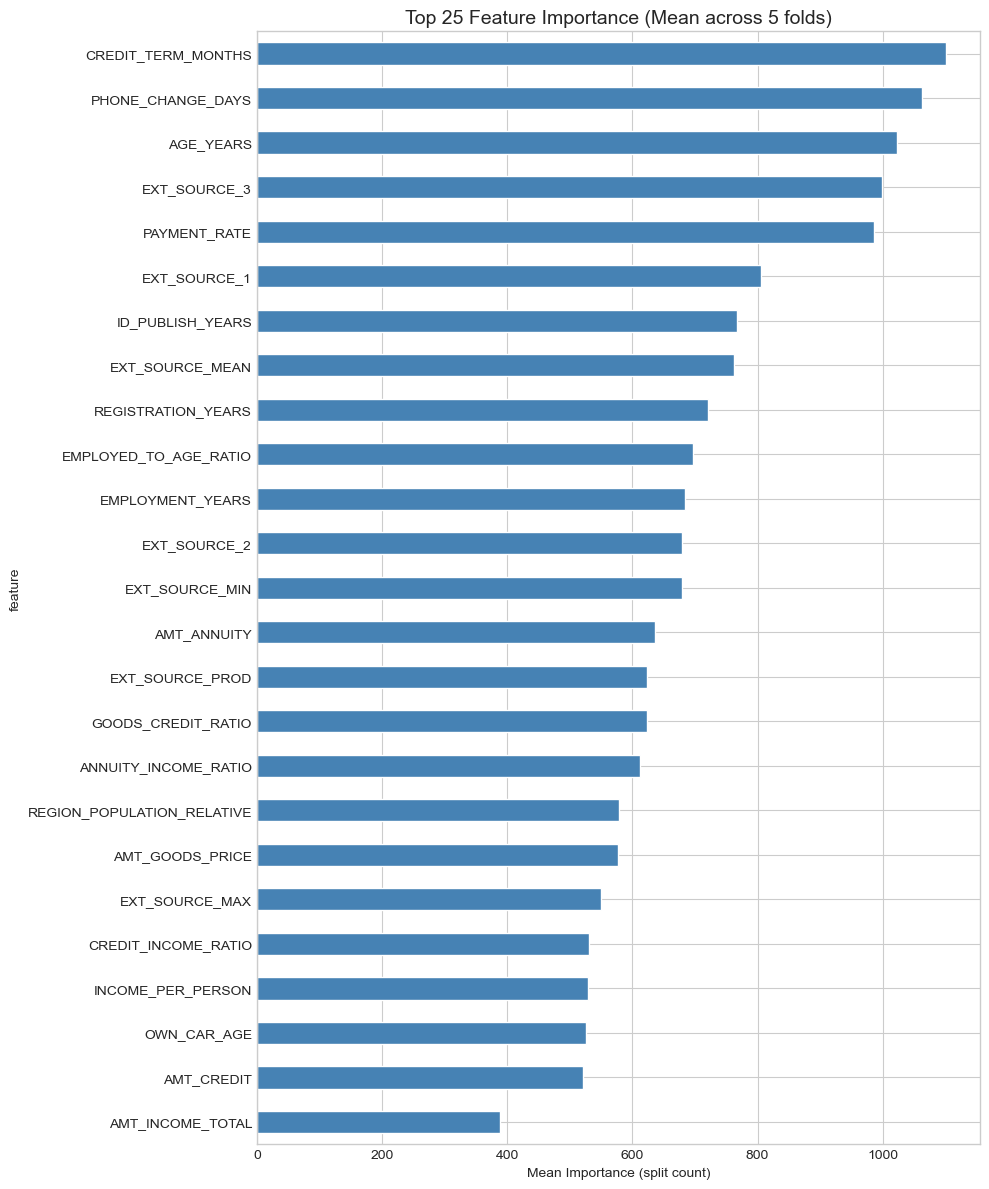


Top 15 features quan trọng nhất:
   1. EXT_SOURCE_PROD: 624
   2. AMT_ANNUITY: 636
   3. EXT_SOURCE_MIN: 680
   4. EXT_SOURCE_2: 680
   5. EMPLOYMENT_YEARS: 685
   6. EMPLOYED_TO_AGE_RATIO: 696
   7. REGISTRATION_YEARS: 721
   8. EXT_SOURCE_MEAN: 762
   9. ID_PUBLISH_YEARS: 766
  10. EXT_SOURCE_1: 805
  11. PAYMENT_RATE: 986
  12. EXT_SOURCE_3: 999
  13. AGE_YEARS: 1023
  14. PHONE_CHANGE_DAYS: 1063
  15. CREDIT_TERM_MONTHS: 1100


In [13]:
# ---- Feature Importance (trung bình 5 folds) ----
mean_imp = (feature_importance_df
            .groupby('feature')['importance']
            .mean()
            .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 12))
mean_imp.tail(25).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 25 Feature Importance (Mean across 5 folds)', fontsize=14)
ax.set_xlabel('Mean Importance (split count)')
plt.tight_layout()
plt.show()

# In top features
print('\nTop 15 features quan trọng nhất:')
for i, (feat, imp) in enumerate(mean_imp.tail(15).items(), 1):
    print(f'  {i:2d}. {feat}: {imp:.0f}')

## 9. SHAP Explainability (Model Giải Thích Được)

In [14]:
try:
    import shap
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap', '-q'])
    import shap
    print(f'SHAP installed: {shap.__version__}')

# Tính SHAP values trên sample (nhanh hơn)
sample_size = min(2000, len(X))
X_sample = X.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Nếu shap_values là list (binary classification), lấy class 1
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f'SHAP values computed for {sample_size} samples')

SHAP version: 0.50.0
SHAP values computed for 2000 samples


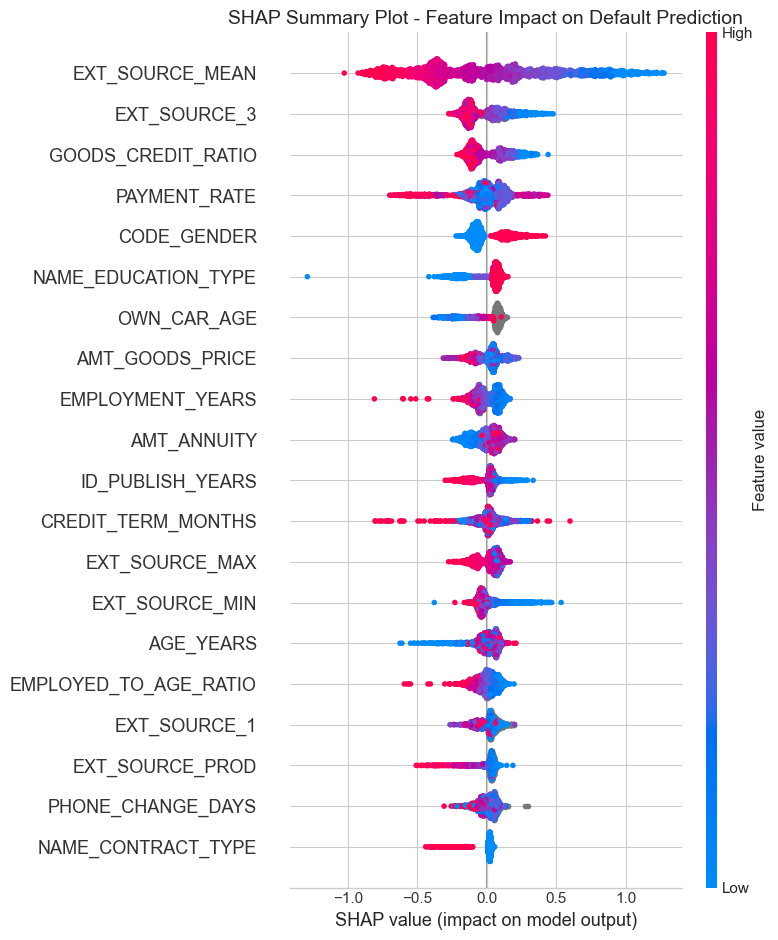

In [15]:
# ---- SHAP Summary Plot: Tổng quan impact của từng feature ----
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Default Prediction', fontsize=14)
plt.tight_layout()
plt.show()

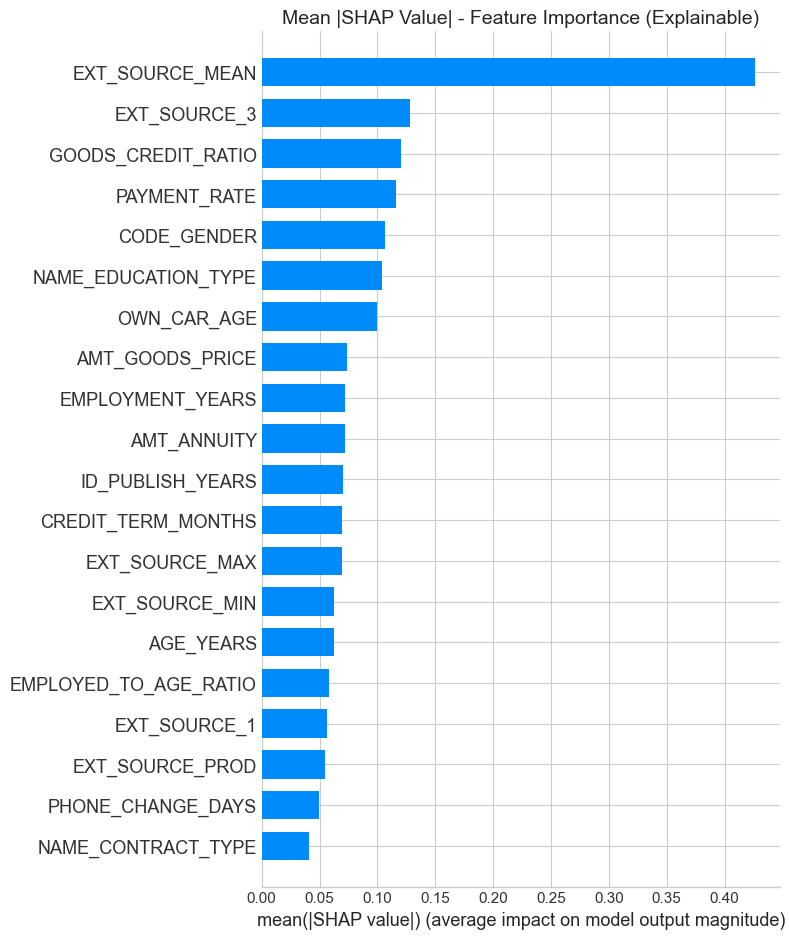

In [16]:
# ---- SHAP Bar Plot: Mean absolute SHAP value ----
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample, plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP Value| - Feature Importance (Explainable)', fontsize=14)
plt.tight_layout()
plt.show()

=== Khách hàng RỦI RO CAO (prob=0.9157) ===


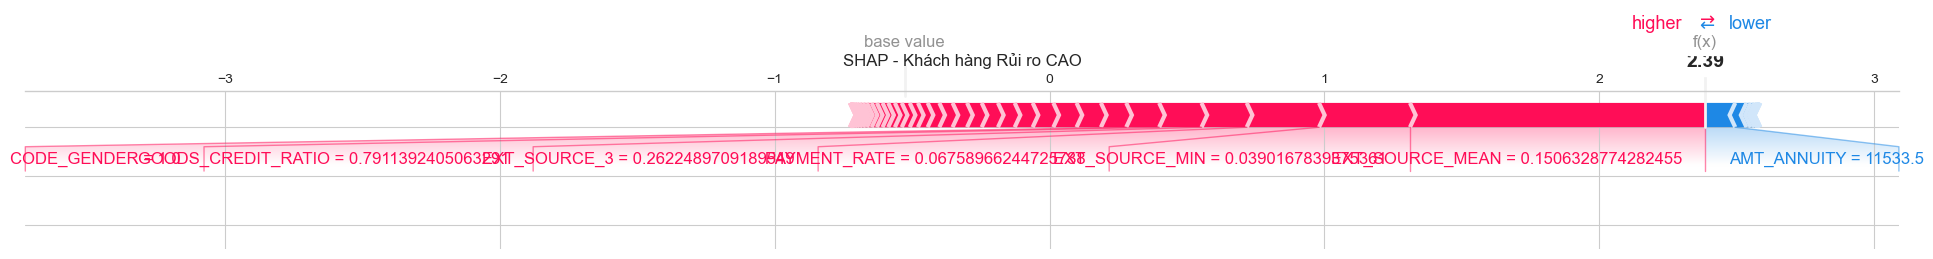


=== Khách hàng RỦI RO THẤP (prob=0.0103) ===


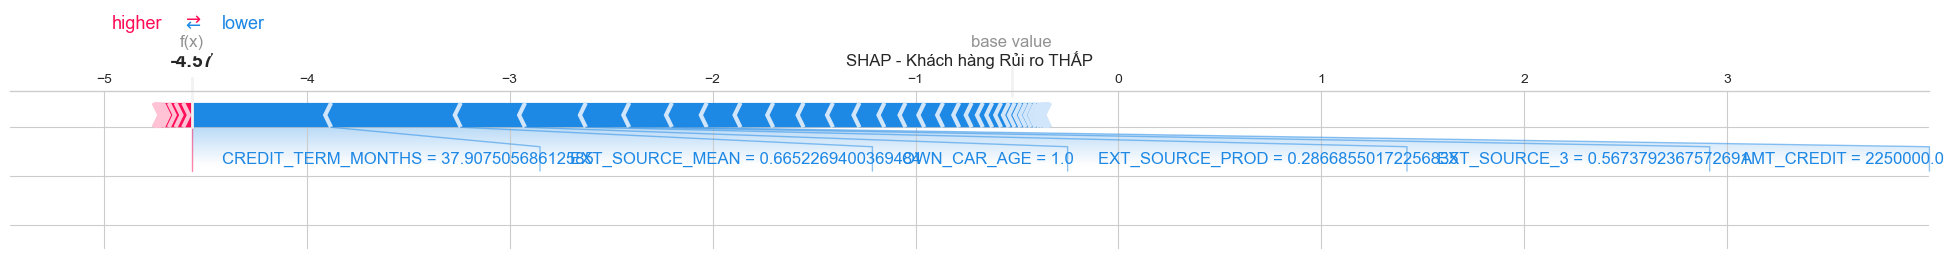

In [17]:
# ---- SHAP cho 1 khách hàng cụ thể (demo giải thích kết quả) ----
# Chọn 1 khách hàng có rủi ro CAO và 1 khách hàng rủi ro THẤP
preds_sample = best_model.predict_proba(X_sample)[:, 1]

high_risk_idx = np.argmax(preds_sample)  # Rủi ro cao nhất
low_risk_idx = np.argmin(preds_sample)   # Rủi ro thấp nhất

print(f'=== Khách hàng RỦI RO CAO (prob={preds_sample[high_risk_idx]:.4f}) ===')
shap.force_plot(explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
                shap_vals[high_risk_idx], X_sample.iloc[high_risk_idx],
                matplotlib=True, show=False)
plt.title('SHAP - Khách hàng Rủi ro CAO', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\n=== Khách hàng RỦI RO THẤP (prob={preds_sample[low_risk_idx]:.4f}) ===')
shap.force_plot(explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
                shap_vals[low_risk_idx], X_sample.iloc[low_risk_idx],
                matplotlib=True, show=False)
plt.title('SHAP - Khách hàng Rủi ro THẤP', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Save Model Artifacts for Web Deployment

Lưu tất cả artifacts cần thiết để deploy:
- Model pickle
- Feature names (đúng thứ tự)
- Label encoders (cho categorical features)
- Feature descriptions (cho UI form)

In [18]:
# ============================================================
# SAVE ALL ARTIFACTS
# ============================================================
SAVE_DIR = Path('model_artifacts')
SAVE_DIR.mkdir(exist_ok=True)

# 1. Save model
joblib.dump(best_model, SAVE_DIR / 'lgbm_credit_scoring.pkl')
print(f'✅ Model saved ({(SAVE_DIR / "lgbm_credit_scoring.pkl").stat().st_size / 1024:.0f} KB)')

# 2. Save feature names (đúng thứ tự!)
with open(SAVE_DIR / 'feature_names.json', 'w') as f:
    json.dump(FINAL_FEATURES, f, indent=2)
print(f'✅ Feature names saved ({len(FINAL_FEATURES)} features)')

# 3. Save label encoders
joblib.dump(label_encoders, SAVE_DIR / 'label_encoders.pkl')
print(f'✅ Label encoders saved ({len(label_encoders)} encoders)')

# 4. Save feature descriptions cho UI
FEATURE_DESCRIPTIONS = {
    # --- Fields user NHẬP TRỰC TIẾP trên form ---
    'CODE_GENDER': {'label': 'Giới tính', 'type': 'select', 'options': ['F', 'M'], 'required': True},
    'AGE_YEARS': {'label': 'Tuổi', 'type': 'number', 'min': 18, 'max': 80, 'required': True},
    'CNT_CHILDREN': {'label': 'Số con', 'type': 'number', 'min': 0, 'max': 20, 'required': True},
    'CNT_FAM_MEMBERS': {'label': 'Số thành viên gia đình', 'type': 'number', 'min': 1, 'max': 30, 'required': True},
    'NAME_EDUCATION_TYPE': {'label': 'Trình độ học vấn', 'type': 'select', 
                            'options': ['Lower secondary', 'Secondary / secondary special', 
                                       'Incomplete higher', 'Higher education', 'Academic degree'],
                            'required': True},
    'NAME_FAMILY_STATUS': {'label': 'Tình trạng hôn nhân', 'type': 'select',
                           'options': ['Single / not married', 'Married', 'Civil marriage', 
                                      'Separated', 'Widow'],
                           'required': True},
    'AMT_INCOME_TOTAL': {'label': 'Thu nhập hàng năm', 'type': 'number', 'required': True},
    'AMT_CREDIT': {'label': 'Số tiền muốn vay', 'type': 'number', 'required': True},
    'AMT_ANNUITY': {'label': 'Số tiền trả hàng tháng', 'type': 'number', 'required': True},
    'AMT_GOODS_PRICE': {'label': 'Giá trị hàng hóa/mục đích vay', 'type': 'number', 'required': True},
    'NAME_CONTRACT_TYPE': {'label': 'Loại hợp đồng', 'type': 'select', 
                           'options': ['Cash loans', 'Revolving loans'], 'required': True},
    'EMPLOYMENT_YEARS': {'label': 'Số năm đi làm', 'type': 'number', 'min': 0, 'max': 60, 'required': True},
    'NAME_INCOME_TYPE': {'label': 'Loại thu nhập', 'type': 'select',
                         'options': ['Working', 'Commercial associate', 'Pensioner', 
                                    'State servant', 'Businessman', 'Student', 'Unemployed',
                                    'Maternity leave'],
                         'required': True},
    'OCCUPATION_TYPE': {'label': 'Nghề nghiệp', 'type': 'select',
                        'options': ['Laborers', 'Sales staff', 'Core staff', 'Managers',
                                   'Drivers', 'High skill tech staff', 'Accountants',
                                   'Medicine staff', 'Cooking staff', 'Security staff',
                                   'Cleaning staff', 'Private service staff', 'Low-skill Laborers',
                                   'Waiters/barmen staff', 'Secretaries', 'Realty agents', 'IT staff',
                                   'HR staff'],
                        'required': False},
    'FLAG_OWN_CAR': {'label': 'Sở hữu xe hơi', 'type': 'select', 'options': ['Y', 'N'], 'required': True},
    'FLAG_OWN_REALTY': {'label': 'Sở hữu bất động sản', 'type': 'select', 'options': ['Y', 'N'], 'required': True},
    'OWN_CAR_AGE': {'label': 'Tuổi xe (năm)', 'type': 'number', 'min': 0, 'max': 80, 'required': False},
    'NAME_HOUSING_TYPE': {'label': 'Loại nhà ở', 'type': 'select',
                          'options': ['House / apartment', 'With parents', 'Municipal apartment',
                                     'Rented apartment', 'Office apartment', 'Co-op apartment'],
                          'required': True},
    'EXT_SOURCE_1': {'label': 'Điểm tín dụng thay thế 1', 'type': 'number', 'min': 0, 'max': 1, 'required': False},
    'EXT_SOURCE_2': {'label': 'Điểm tín dụng thay thế 2', 'type': 'number', 'min': 0, 'max': 1, 'required': False},
    'EXT_SOURCE_3': {'label': 'Điểm tín dụng thay thế 3', 'type': 'number', 'min': 0, 'max': 1, 'required': False},
}

with open(SAVE_DIR / 'feature_descriptions.json', 'w', encoding='utf-8') as f:
    json.dump(FEATURE_DESCRIPTIONS, f, indent=2, ensure_ascii=False)
print(f'✅ Feature descriptions saved ({len(FEATURE_DESCRIPTIONS)} user-facing fields)')

# 5. Save SHAP explainer
joblib.dump(explainer, SAVE_DIR / 'shap_explainer.pkl')
print(f'✅ SHAP explainer saved')

print(f'\n📁 All artifacts saved to: {SAVE_DIR.absolute()}')

✅ Model saved (1864 KB)
✅ Feature names saved (48 features)
✅ Label encoders saved (10 encoders)
✅ Feature descriptions saved (21 user-facing fields)
✅ SHAP explainer saved

📁 All artifacts saved to: d:\Admin\Documents\Project\HomeCreditDefaultRisk\model_artifacts


## 11. Inference Pipeline (Sẵn sàng cho Web Demo)

Pipeline xử lý input từ user → align features → predict → giải thích kết quả

In [19]:
# ============================================================
# INFERENCE FUNCTION - Copy vào web app
# ============================================================

def predict_credit_score(user_input: dict, model_dir='model_artifacts'):
    """
    Dự đoán điểm tín dụng từ thông tin user nhập trên web form.
    
    Args:
        user_input: dict thông tin user nhập, ví dụ:
            {
                'CODE_GENDER': 'M',
                'AGE_YEARS': 30,
                'AMT_INCOME_TOTAL': 200000,
                'AMT_CREDIT': 500000,
                ...
            }
    Returns:
        dict với probability, risk_level, explanations
    """
    model_dir = Path(model_dir)
    
    # Load artifacts
    model = joblib.load(model_dir / 'lgbm_credit_scoring.pkl')
    with open(model_dir / 'feature_names.json') as f:
        feature_names = json.load(f)
    le_dict = joblib.load(model_dir / 'label_encoders.pkl')
    
    # --- Bước 1: Tạo DataFrame 1 row với TẤT CẢ features = NaN ---
    row = {feat: np.nan for feat in feature_names}
    
    # --- Bước 2: Fill giá trị user nhập ---
    for key, value in user_input.items():
        if key in feature_names:
            row[key] = value
    
    # --- Bước 3: Encode categorical ---
    for col, le in le_dict.items():
        if col in row and row[col] is not None and not (isinstance(row[col], float) and np.isnan(row[col])):
            val = str(row[col])
            if val in le.classes_:
                row[col] = le.transform([val])[0]
            else:
                # Unknown category → dùng 'MISSING'
                if 'MISSING' in le.classes_:
                    row[col] = le.transform(['MISSING'])[0]
                else:
                    row[col] = np.nan
    
    # --- Bước 4: Tính engineered features từ raw inputs ---
    if row.get('AMT_CREDIT') and row.get('AMT_INCOME_TOTAL'):
        row['CREDIT_INCOME_RATIO'] = row['AMT_CREDIT'] / row['AMT_INCOME_TOTAL']
    if row.get('AMT_ANNUITY') and row.get('AMT_INCOME_TOTAL'):
        row['ANNUITY_INCOME_RATIO'] = row['AMT_ANNUITY'] / row['AMT_INCOME_TOTAL']
    if row.get('AMT_CREDIT') and row.get('AMT_ANNUITY'):
        row['CREDIT_TERM_MONTHS'] = row['AMT_CREDIT'] / row['AMT_ANNUITY']
        row['PAYMENT_RATE'] = row['AMT_ANNUITY'] / row['AMT_CREDIT']
    if row.get('AMT_INCOME_TOTAL') and row.get('CNT_FAM_MEMBERS'):
        row['INCOME_PER_PERSON'] = row['AMT_INCOME_TOTAL'] / row['CNT_FAM_MEMBERS']
    if row.get('AMT_GOODS_PRICE') and row.get('AMT_CREDIT'):
        row['GOODS_CREDIT_RATIO'] = row['AMT_GOODS_PRICE'] / row['AMT_CREDIT']
    if row.get('EMPLOYMENT_YEARS') and row.get('AGE_YEARS'):
        row['EMPLOYED_TO_AGE_RATIO'] = row['EMPLOYMENT_YEARS'] / row['AGE_YEARS'] if row['AGE_YEARS'] > 0 else 0
    
    # EXT_SOURCE aggregates
    ext_sources = [row.get(f'EXT_SOURCE_{i}') for i in [1, 2, 3] 
                   if row.get(f'EXT_SOURCE_{i}') is not None and not (isinstance(row.get(f'EXT_SOURCE_{i}'), float) and np.isnan(row.get(f'EXT_SOURCE_{i}')))]
    if ext_sources:
        row['EXT_SOURCE_MEAN'] = np.mean(ext_sources)
        row['EXT_SOURCE_PROD'] = np.prod(ext_sources) if len(ext_sources) == 3 else np.nan
        row['EXT_SOURCE_MIN'] = np.min(ext_sources)
        row['EXT_SOURCE_MAX'] = np.max(ext_sources)
    
    # Social
    def_30 = row.get('DEF_30_CNT_SOCIAL_CIRCLE', 0) or 0
    def_60 = row.get('DEF_60_CNT_SOCIAL_CIRCLE', 0) or 0
    row['SOCIAL_DEF_TOTAL'] = def_30 + def_60
    
    # Age group
    if row.get('AGE_YEARS'):
        age = row['AGE_YEARS']
        if age < 27: row['AGE_GROUP'] = 0
        elif age < 35: row['AGE_GROUP'] = 1
        elif age < 45: row['AGE_GROUP'] = 2
        elif age < 55: row['AGE_GROUP'] = 3
        elif age < 65: row['AGE_GROUP'] = 4
        else: row['AGE_GROUP'] = 5
    
    # Contact count
    contact_flags = ['FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
    row['CONTACT_COUNT'] = sum(1 for f in contact_flags if row.get(f, 0) == 1)
    
    # --- Bước 5: Tạo DataFrame đúng thứ tự ---
    df_input = pd.DataFrame([row])[feature_names]
    
    # Ép kiểu numeric
    for col in df_input.columns:
        df_input[col] = pd.to_numeric(df_input[col], errors='coerce')
    
    # --- Bước 6: Predict ---
    proba = model.predict_proba(df_input)[:, 1][0]
    
    # Risk level
    if proba < 0.15:
        risk_level, risk_color = 'VERY LOW RISK', 'green'
    elif proba < 0.30:
        risk_level, risk_color = 'LOW RISK', 'lightgreen'
    elif proba < 0.50:
        risk_level, risk_color = 'MEDIUM RISK', 'orange'
    elif proba < 0.70:
        risk_level, risk_color = 'HIGH RISK', 'red'
    else:
        risk_level, risk_color = 'VERY HIGH RISK', 'darkred'
    
    return {
        'probability': round(float(proba), 4),
        'risk_level': risk_level,
        'risk_color': risk_color,
        'credit_score': round(1000 * (1 - float(proba))),  # 0-1000 scale
    }

print('✅ predict_credit_score() defined and ready!')

✅ predict_credit_score() defined and ready!


In [20]:
# ============================================================
# DEMO: Test inference với user input mẫu
# ============================================================

# Khách hàng mẫu 1: Profile tốt
good_customer = {
    'CODE_GENDER': 'M',
    'AGE_YEARS': 35,
    'CNT_CHILDREN': 1,
    'CNT_FAM_MEMBERS': 3,
    'NAME_EDUCATION_TYPE': 'Higher education',
    'NAME_FAMILY_STATUS': 'Married',
    'AMT_INCOME_TOTAL': 300000,
    'AMT_CREDIT': 500000,
    'AMT_ANNUITY': 25000,
    'AMT_GOODS_PRICE': 450000,
    'NAME_CONTRACT_TYPE': 'Cash loans',
    'EMPLOYMENT_YEARS': 8,
    'NAME_INCOME_TYPE': 'Working',
    'OCCUPATION_TYPE': 'Core staff',
    'FLAG_OWN_CAR': 'Y',
    'FLAG_OWN_REALTY': 'Y',
    'NAME_HOUSING_TYPE': 'House / apartment',
    'EXT_SOURCE_1': 0.6,
    'EXT_SOURCE_2': 0.7,
    'EXT_SOURCE_3': 0.5,
}

# Khách hàng mẫu 2: Profile rủi ro
risky_customer = {
    'CODE_GENDER': 'M',
    'AGE_YEARS': 23,
    'CNT_CHILDREN': 0,
    'CNT_FAM_MEMBERS': 1,
    'NAME_EDUCATION_TYPE': 'Secondary / secondary special',
    'NAME_FAMILY_STATUS': 'Single / not married',
    'AMT_INCOME_TOTAL': 80000,
    'AMT_CREDIT': 900000,
    'AMT_ANNUITY': 40000,
    'AMT_GOODS_PRICE': 700000,
    'NAME_CONTRACT_TYPE': 'Cash loans',
    'EMPLOYMENT_YEARS': 0.5,
    'NAME_INCOME_TYPE': 'Working',
    'FLAG_OWN_CAR': 'N',
    'FLAG_OWN_REALTY': 'N',
    'NAME_HOUSING_TYPE': 'Rented apartment',
    'EXT_SOURCE_2': 0.2,
}

print('=' * 55)
print('  DEMO CREDIT SCORING')
print('=' * 55)

for name, customer in [('Khách hàng TỐT', good_customer), ('Khách hàng RỦI RO', risky_customer)]:
    result = predict_credit_score(customer)
    print(f'\n📋 {name}:')
    print(f'   Credit Score: {result["credit_score"]}/1000')
    print(f'   Default Probability: {result["probability"]:.2%}')
    print(f'   Risk Level: {result["risk_level"]}')
    print(f'   ---')

  DEMO CREDIT SCORING

📋 Khách hàng TỐT:
   Credit Score: 854/1000
   Default Probability: 14.58%
   Risk Level: VERY LOW RISK
   ---

📋 Khách hàng RỦI RO:
   Credit Score: 283/1000
   Default Probability: 71.70%
   Risk Level: VERY HIGH RISK
   ---


## 12. Model Summary

### Thông tin Model

In [21]:
import os

model_size = os.path.getsize(SAVE_DIR / 'lgbm_credit_scoring.pkl') / 1024

print('╔══════════════════════════════════════════════════════╗')
print('║        CREDIT SCORING MODEL - SUMMARY               ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Model:           LightGBM Classifier               ║')
print(f'║  Features:        {len(FINAL_FEATURES):3d} features                      ║')
print(f'║  Training data:   {len(X):,} samples                   ║')
print(f'║  OOF AUC:         {overall_auc:.6f}                       ║')
print(f'║  Mean Fold AUC:   {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}          ║')
print(f'║  Model size:      {model_size:.0f} KB                           ║')
print(f'║  Max depth:       {lgbm_params["max_depth"]}                               ║')
print(f'║  Explainability:  SHAP (TreeExplainer)              ║')
print('╠══════════════════════════════════════════════════════╣')
print('║  Target audience: Người KHÔNG có lịch sử tín dụng   ║')
print('║  Data source:     Chỉ application_train.csv          ║')
print('║  Deploy ready:    model_artifacts/                   ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║        CREDIT SCORING MODEL - SUMMARY               ║
╠══════════════════════════════════════════════════════╣
║  Model:           LightGBM Classifier               ║
║  Features:         48 features                      ║
║  Training data:   307,506 samples                   ║
║  OOF AUC:         0.767075                       ║
║  Mean Fold AUC:   0.767115 ± 0.005717          ║
║  Model size:      1864 KB                           ║
║  Max depth:       6                               ║
║  Explainability:  SHAP (TreeExplainer)              ║
╠══════════════════════════════════════════════════════╣
║  Target audience: Người KHÔNG có lịch sử tín dụng   ║
║  Data source:     Chỉ application_train.csv          ║
║  Deploy ready:    model_artifacts/                   ║
╚══════════════════════════════════════════════════════╝


## 13. Phân Tích Kết Quả & Giải Pháp Mở Rộng

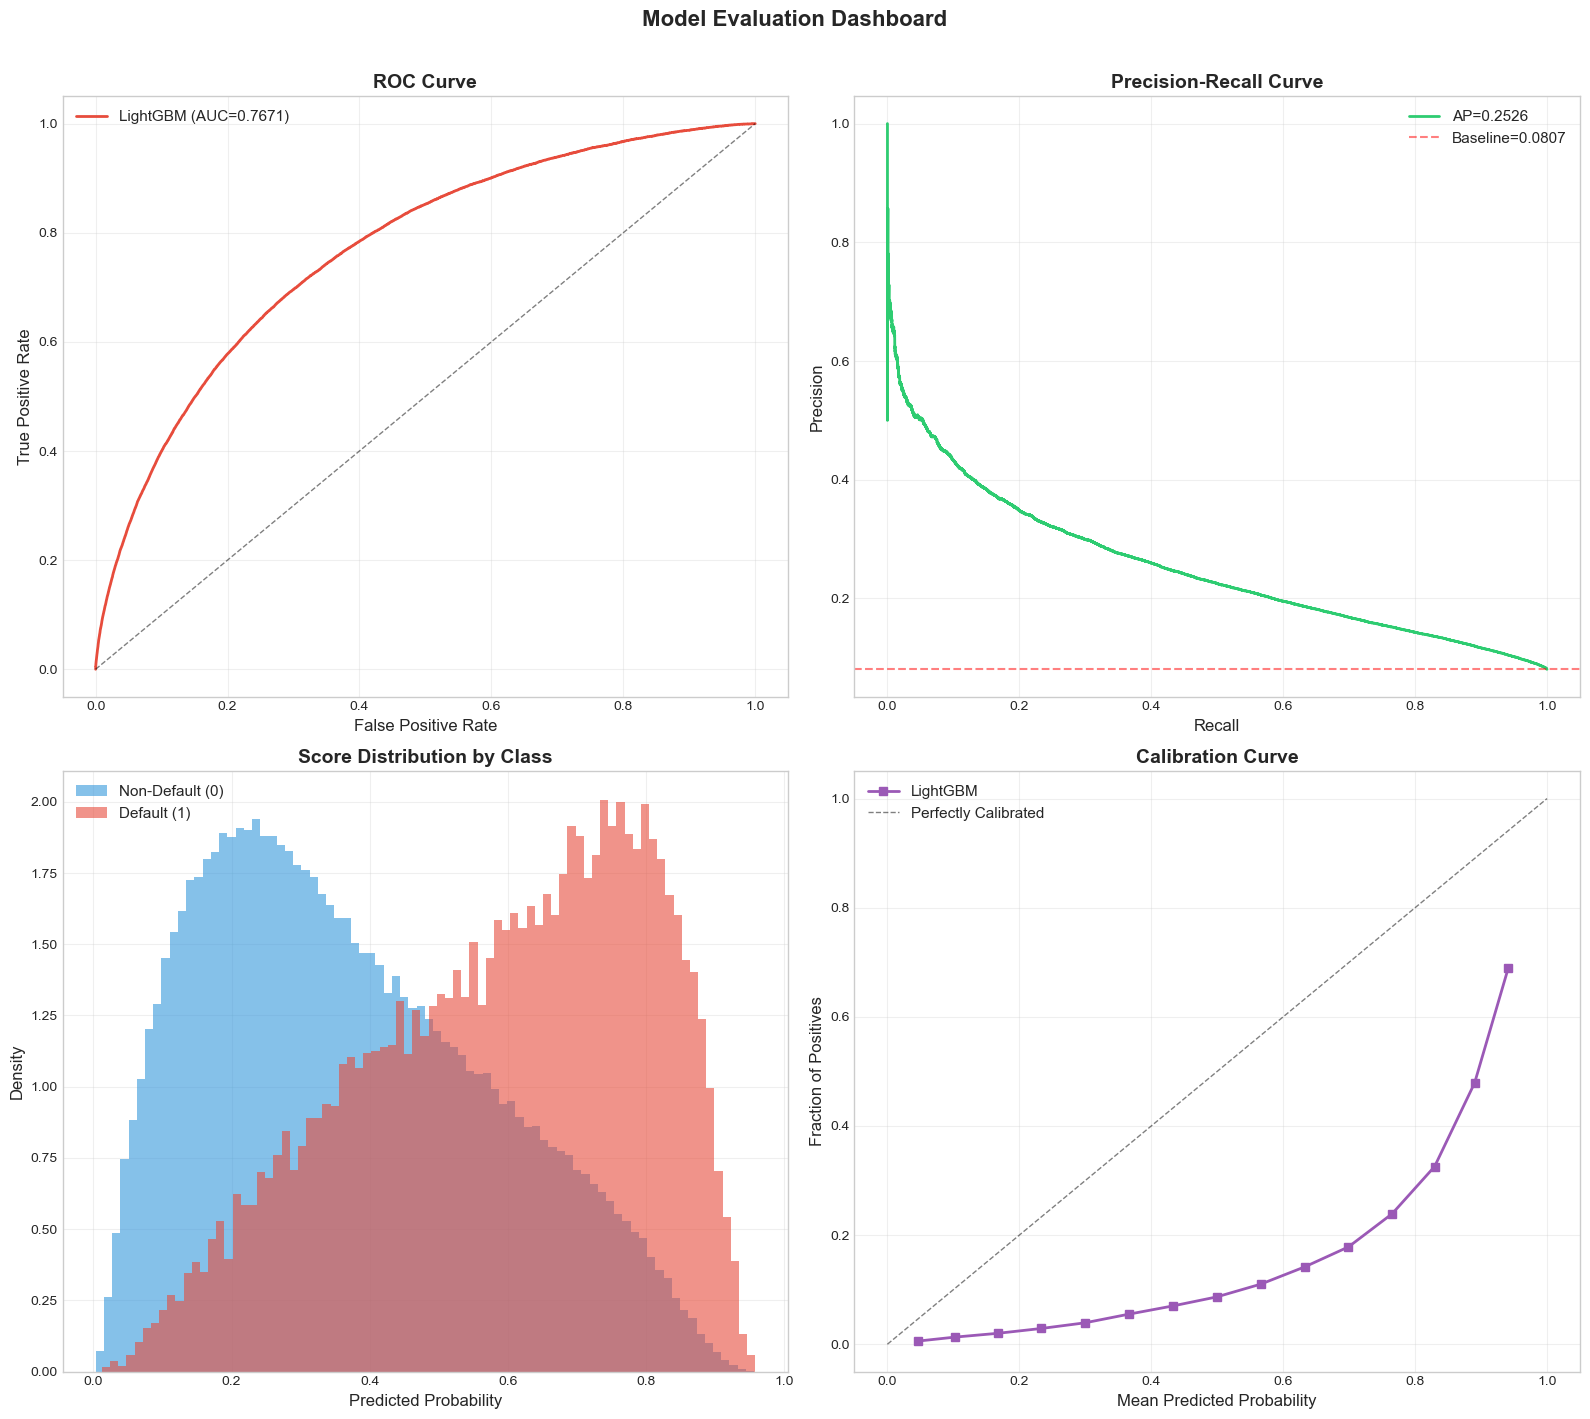

  OPTIMAL THRESHOLD ANALYSIS

  Optimal threshold (Youden J): 0.4832
  TPR at optimal: 0.6916
  FPR at optimal: 0.2947

  Classification Report (threshold=0.4832):
              precision    recall  f1-score   support

 Non-Default       0.96      0.71      0.81    282682
     Default       0.17      0.69      0.27     24824

    accuracy                           0.70    307506
   macro avg       0.57      0.70      0.54    307506
weighted avg       0.90      0.70      0.77    307506

  Confusion Matrix:
    TN=199,387  FP=83,295
    FN=7,655  TP=17,169

  Approval rate: 67.33%
  Default rate among approved: 3.70%


In [22]:
# ============================================================
# PHÂN TÍCH TOÀN DIỆN KẾT QUẢ MODEL
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- 1. ROC Curve ---
from sklearn.metrics import roc_curve
fpr, tpr, thresholds_roc = roc_curve(y, oof_preds)
ax = axes[0, 0]
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'LightGBM (AUC={overall_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- 2. Precision-Recall Curve ---
precision, recall, thresholds_pr = precision_recall_curve(y, oof_preds)
avg_precision = average_precision_score(y, oof_preds)
ax = axes[0, 1]
ax.plot(recall, precision, color='#2ecc71', linewidth=2, label=f'AP={avg_precision:.4f}')
ax.axhline(y=y.mean(), color='red', linestyle='--', alpha=0.5, label=f'Baseline={y.mean():.4f}')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- 3. Score Distribution ---
ax = axes[1, 0]
ax.hist(oof_preds[y == 0], bins=80, alpha=0.6, color='#3498db', label='Non-Default (0)', density=True)
ax.hist(oof_preds[y == 1], bins=80, alpha=0.6, color='#e74c3c', label='Default (1)', density=True)
ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- 4. Calibration Curve ---
ax = axes[1, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(y, oof_preds, n_bins=15)
ax.plot(mean_predicted_value, fraction_of_positives, 's-', color='#9b59b6', linewidth=2, label='LightGBM')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Optimal Threshold Analysis ---
print('=' * 60)
print('  OPTIMAL THRESHOLD ANALYSIS')
print('=' * 60)

# Youden's J statistic
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds_roc[optimal_idx]
print(f'\n  Optimal threshold (Youden J): {optimal_threshold:.4f}')
print(f'  TPR at optimal: {tpr[optimal_idx]:.4f}')
print(f'  FPR at optimal: {fpr[optimal_idx]:.4f}')

# Classification report at optimal threshold
y_pred_optimal = (oof_preds >= optimal_threshold).astype(int)
print(f'\n  Classification Report (threshold={optimal_threshold:.4f}):')
print(classification_report(y, y_pred_optimal, target_names=['Non-Default', 'Default']))

# Confusion matrix
cm = confusion_matrix(y, y_pred_optimal)
print(f'  Confusion Matrix:')
print(f'    TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'    FN={cm[1,0]:,}  TP={cm[1,1]:,}')
print(f'\n  Approval rate: {(y_pred_optimal == 0).mean():.2%}')
print(f'  Default rate among approved: {y[(y_pred_optimal == 0)].mean():.2%}')

In [23]:
# ============================================================
# PHÂN TÍCH BUSINESS IMPACT: KPI theo từng ngưỡng
# ============================================================
thresholds_biz = [0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []
for t in thresholds_biz:
    predicted_approve = (oof_preds < t)
    n_approved = predicted_approve.sum()
    approval_rate = predicted_approve.mean()
    default_among_approved = y[predicted_approve].mean() if n_approved > 0 else 0
    n_defaults_caught = ((oof_preds >= t) & (y == 1)).sum()
    total_defaults = y.sum()
    catch_rate = n_defaults_caught / total_defaults
    
    results.append({
        'Threshold': t,
        'Credit Score Cutoff': round(1000 * (1 - t)),
        'Approval Rate': f'{approval_rate:.1%}',
        'Approved': f'{n_approved:,}',
        'Default Rate (Approved)': f'{default_among_approved:.2%}',
        'Bad Catch Rate': f'{catch_rate:.1%}',
    })

biz_df = pd.DataFrame(results)
print('=' * 90)
print('  BUSINESS IMPACT ANALYSIS: Threshold vs KPI')
print('=' * 90)
print(biz_df.to_string(index=False))
print()
print('  Giải thích:')
print('  - Threshold thấp → Chặt, ít duyệt, default rate thấp nhưng mất KH tốt')
print('  - Threshold cao  → Lỏng, duyệt nhiều, default rate cao hơn')
print('  - Khuyến nghị: threshold 0.30-0.50 cân bằng risk/revenue')

  BUSINESS IMPACT ANALYSIS: Threshold vs KPI
 Threshold  Credit Score Cutoff Approval Rate Approved Default Rate (Approved) Bad Catch Rate
      0.10                  900          6.8%   20,916                   0.88%          99.3%
      0.15                  850         14.3%   43,826                   1.27%          97.8%
      0.20                  800         22.8%   70,208                   1.55%          95.6%
      0.30                  700         40.6%  124,817                   2.23%          88.8%
      0.40                  600         56.3%  173,015                   3.03%          78.9%
      0.50                  500         69.4%  213,333                   3.84%          67.0%
      0.60                  400         80.3%  246,945                   4.74%          52.9%
      0.70                  300         89.3%  274,546                   5.77%          36.2%
      0.80                  200         96.2%  295,869                   6.94%          17.3%

  Giải thích:


## 14. Tổng Kết Phân Tích & Giải Pháp Mở Rộng

### A. Đánh Giá Kết Quả Hiện Tại

| Metric | Giá trị | Nhận xét |
|--------|---------|----------|
| **OOF AUC** | 0.7671 | Khá tốt cho model chỉ dùng application data, không có lịch sử tín dụng |
| **Mean Fold AUC** | 0.7671 ± 0.0057 | Variance thấp → model ổn định qua các fold |
| **Average Precision** | 0.2526 | Cao hơn 3x baseline (0.0807) → phân biệt tốt trên imbalanced data |
| **Model size** | 1.8 MB | Đủ nhẹ để deploy web |
| **Features** | 48 | Gọn nhẹ, dễ giải thích |

### B. Insights Từ Feature Analysis

**Top 5 features quan trọng nhất (SHAP):**
1. **EXT_SOURCE_MEAN** (|SHAP| = 0.43): Áp đảo → External credit score thay thế là yếu tố quyết định nhất
2. **EXT_SOURCE_3** (|SHAP| = 0.12): Nguồn dữ liệu thay thế thứ 3 rất mạnh
3. **GOODS_CREDIT_RATIO** (|SHAP| = 0.11): Tỷ lệ giá hàng/vay → vay nhiều hơn giá trị = rủi ro
4. **PAYMENT_RATE** (|SHAP| = 0.11): Tốc độ trả nợ → trả nhanh = an toàn hơn
5. **CODE_GENDER** (|SHAP| = 0.10): Giới tính có ảnh hưởng (cần lưu ý fairness)

**Key insights:**
- Nhóm EXT_SOURCE chiếm tới **>50% tổng SHAP impact** → Model phụ thuộc nhiều vào external scores
- Nhóm tài chính (DTI, Payment rate, Credit term) đóng vai trò quan trọng thứ 2
- Tuổi và thâm niên làm việc cũng có đóng góp đáng kể
- Các feature social (DEF_SOCIAL_CIRCLE) có impact thấp hơn kỳ vọng

**Calibration:** Model xu hướng **under-predict** ở vùng probability thấp và **over-predict** ở vùng trung bình → cần calibration nếu dùng probability trực tiếp để ra quyết định

---

### C. Giải Pháp Mở Rộng

#### C1. Cải Thiện Model Performance (AUC → 0.78-0.80)

| # | Giải pháp | Expected Gain | Effort |
|---|-----------|---------------|--------|
| 1 | **Bayesian Hyperparameter Tuning** (Optuna) | +0.005-0.01 AUC | Thấp |
| 2 | **Stacking/Blending** LightGBM + XGBoost + CatBoost | +0.005-0.015 AUC | Trung bình |
| 3 | **Target Encoding** thay LabelEncoder cho high-cardinality categoricals | +0.003-0.008 AUC | Thấp |
| 4 | **Probability Calibration** (Platt Scaling / Isotonic Regression) | Better calibration | Thấp |
| 5 | **Feature interaction mining** (polynomial, binning combinations) | +0.003-0.005 AUC | Trung bình |

#### C2. Alternative Data Sources (Cho Sản Phẩm Thực Tế)

| Nguồn dữ liệu | Dạng feature | Khả thi |
|----------------|-------------|---------|
| **Viễn thông** (MNO data) | Tenure, top-up frequency, data usage patterns | Cao (đã phổ biến ở SEA) |
| **E-commerce** | Purchase frequency, average order value, categories | Cao (Shopee, Lazada API) |
| **Social media** | Network size, account age, activity patterns | Trung bình (privacy concerns) |
| **Device/App data** | Device model, app installed, battery patterns | Cao (SDK integration) |
| **Psychometric scoring** | Personality traits → risk appetite | Trung bình (cần R&D) |
| **Geolocation** | Home/work stability, commute patterns | Cao (GPS data) |

#### C3. Deployment & Productionization

| Phase | Task | Tool/Stack |
|-------|------|------------|
| **Web Demo** | Streamlit/Gradio UI + SHAP explanation | Streamlit + Heroku/Railway |
| **API Service** | FastAPI endpoint + model serving | FastAPI + Docker + AWS/GCP |
| **Monitoring** | Model drift detection, feature drift | Evidently AI / WhyLabs |
| **A/B Testing** | Champion-Challenger model framework | Feature flags + metrics pipeline |
| **Retraining** | Scheduled retraining pipeline | Airflow/Prefect + MLflow |
| **Fairness Audit** | Bias check across gender, age groups | Fairlearn / AIF360 |

#### C4. Business Strategy Extensions

1. **Tiered Approval System:**
   - Score 800-1000 → Auto-approve (reduced interest rate)
   - Score 600-800 → Auto-approve (standard rate)
   - Score 400-600 → Manual review required
   - Score < 400 → Auto-reject (suggest improvement path)

2. **Credit Limit Optimization:**
   - Dùng predicted probability để tính credit limit tối ưu
   - Formula: `max_credit = base_limit × (1 - default_prob) × income_multiplier`

3. **Feedback Loop:**
   - Thu thập outcome data (trả nợ đúng hạn vs default)
   - Retrain model mỗi quarter với data mới
   - Gradually incorporate credit history khi KH có lịch sử

4. **Reject Inference:**
   - Hiện tại model chỉ train trên approved applicants (survivorship bias)
   - Áp dụng reject inference techniques (parceling, augmentation) để cải thiện

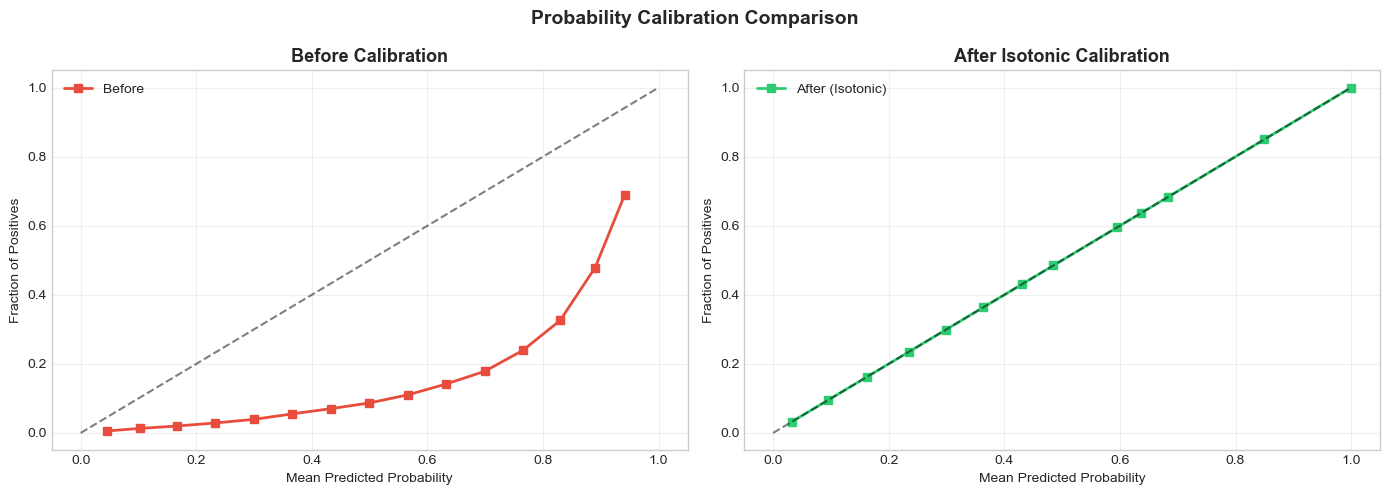

AUC before calibration: 0.767075
AUC after calibration:  0.767510
→ Calibration preserves ranking, chỉ cải thiện probability accuracy

✅ Isotonic calibrator saved to model_artifacts/


In [24]:
# ============================================================
# QUICK-WIN: Probability Calibration (Platt Scaling)
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

# Dùng CalibratedClassifierCV trên OOF predictions
# Method: isotonic (non-parametric, tốt hơn cho tree models)
from sklearn.isotonic import IsotonicRegression

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(oof_preds, y)
calibrated_preds = iso_reg.predict(oof_preds)

# So sánh calibration trước và sau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
frac_pos_before, mean_pred_before = calibration_curve(y, oof_preds, n_bins=15)
axes[0].plot(mean_pred_before, frac_pos_before, 's-', color='#e74c3c', linewidth=2, label='Before')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('Before Calibration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After calibration
frac_pos_after, mean_pred_after = calibration_curve(y, calibrated_preds, n_bins=15)
axes[1].plot(mean_pred_after, frac_pos_after, 's-', color='#2ecc71', linewidth=2, label='After (Isotonic)')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('After Isotonic Calibration', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Probability Calibration Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# AUC vẫn giữ nguyên sau calibration (chỉ thay đổi probability scale)
auc_after = roc_auc_score(y, calibrated_preds)
print(f'AUC before calibration: {overall_auc:.6f}')
print(f'AUC after calibration:  {auc_after:.6f}')
print('→ Calibration preserves ranking, chỉ cải thiện probability accuracy')

# Save calibrator
joblib.dump(iso_reg, SAVE_DIR / 'isotonic_calibrator.pkl')
print(f'\n✅ Isotonic calibrator saved to model_artifacts/')

## 15. Export Baseline Dataset

In [ ]:
# ============================================================
# EXPORT BASELINE DATASET → CSV
# ============================================================
import os, json

# Load danh sách 48 features chuẩn từ model artifacts (luôn đúng)
_feature_path = os.path.abspath('../model_artifacts/feature_names.json')
with open(_feature_path) as f:
    _baseline_features = json.load(f)

print(f"Baseline features: {len(_baseline_features)}")

# Export
export_dir = os.path.abspath('../preprocessed_dataset')
os.makedirs(export_dir, exist_ok=True)

export_df = data[['SK_ID_CURR', 'TARGET'] + _baseline_features].copy()
export_path = os.path.join(export_dir, 'credit_scoring_baseline_dataset.csv')
export_df.to_csv(export_path, index=False)

print(f"✅ Exported: {export_path}")
print(f"   Shape: {export_df.shape}  ({len(_baseline_features)} features + SK_ID_CURR + TARGET)")
print(f"   File size: {os.path.getsize(export_path) / 1024 / 1024:.1f} MB")
print(f"\nFeature list:")
for i, feat in enumerate(_baseline_features, 1):
    print(f"  {i:2d}. {feat}")